In [1]:
from retinotopy import *
import seaborn as sns

Running on GPU :  Tesla V100-SXM2-32GB #GPU= 1
Running on Jean Zay with Tesla V100-SXM2-32GB with DATAROOT='/lustre/fsn1/projects/rech/fsx/uvb28bo/data' and USER='uvb28bo' 


In [2]:

def get_tens_from_path(path):
    transform_tens = T.Compose([ 
                    T.ToImage(),
                    T.ToDtype(torch.float32, scale=True),
                    T.Normalize(mean=im_mean, std=im_std)
    ])
    image = cv2.imread(path)
    image_np = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_tens = transform_tens(image_np)
    imshow(image_tens)
    return (image_np, image_tens)



In [3]:
# The dataset to import images from

data_set_type = 'full'

args = Params()
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
folder = args.folders[0]
args.folders = ['val'] # type of images to use


args.do_saccade = False
args.do_resize = False
args.do_mask = False
args.do_polar = False

BUG?? image_dataset = image_datasets_transforms(args, shuffle=False, verbose=False)
N_image = 1000
np.random.seed(args.seed)
idxs = np.random.permutation(len(image_dataset))[:N_image]

args = Params()
args.size_ratio = 0.1
args.method = 'valid'
args.saccade_type = 'multi'
data_transforms = {}
args.do_saccade = True
args.normalize = False
args.device = device
#args.resolution = (13,13)
for do_polar in [True, False]:
    args.do_polar = do_polar
    data_transforms[do_polar] = get_transforms(args)

do_save = False

model_raw = load_model(model_name='resnet101', model_path=None, do_circular=False).to(device).eval()

SyntaxError: invalid syntax (1831639003.py, line 16)

# With one label

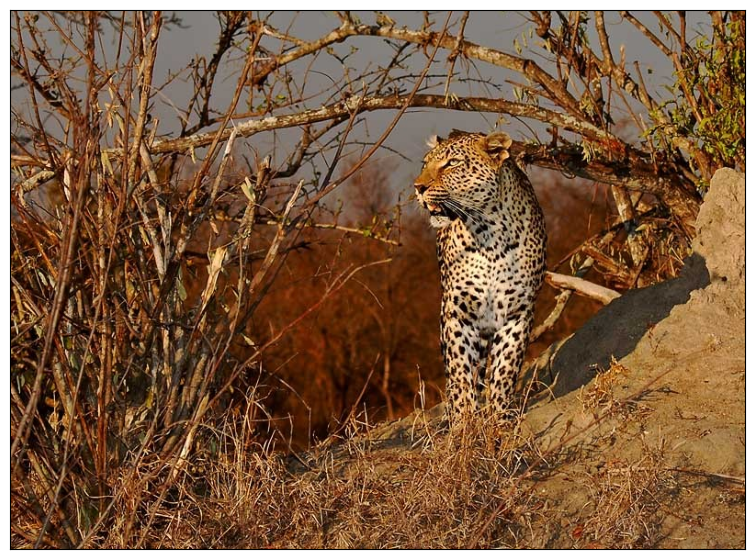

In [4]:
image_np, image_tens = get_tens_from_path('imgs/jaguar_5.jpg')
test_match = i_labels_dico['leopard']# limpkin label

In [5]:
models = {}
model_paths = {}

for model in ['resnet101']:
    for do_polar in [False, True]:
        args.do_polar = do_polar
        model_filename = get_filename('cached_data', datetag, 'bbox', model, do_polar) + '.pt'
        models[model_filename] = load_model(model_name=model, model_path=model_filename, do_circular=args.do_polar).to(device).eval()

likelihood_maps, povs = [], []


with torch.no_grad():
    image_tens = image_tens.to(device)
    
    data_grid = {}

    since_heat = time.time()
        
    data_grid[False] = data_transforms[False](image_tens)
    
    likelihood_map = get_batch(args, model_raw, data_grid[False], 50)

    print(time.time() - since_heat, 'Model raw')

    likelihood_maps.append(likelihood_map)

    likelihood_map = likelihood_map[:,test_match]#.cpu()
    
    povs.append(data_grid[False][np.argmax(likelihood_map)].cpu())
    
    for model_name in models.keys():
        do_polar = True if 'retino' in model_name else False
        args.do_polar = do_polar
        
        since_heat = time.time()
        if do_polar == True:
            data_grid[do_polar] = data_transforms[do_polar](image_tens)
        likelihood_map = get_batch(args, models[model_name], data_grid[do_polar], 50)

        print(time.time() - since_heat, model_name)

        likelihood_maps.append(likelihood_map)

        likelihood_map = likelihood_map[:,test_match]#.cpu()

        
        povs.append(data_grid[False][np.argmax(likelihood_map)].cpu())

display_heat_two(image_np, likelihood_maps, test_match, args.resolution, f'PG_maps', True)
imshow(povs, save=False, name='PG_povs')

loading .... cached_data/2025-03-06_bbox_resnet101_cartesian.pt


loading .... cached_data/2025-03-06_bbox_resnet101_retino.pt


NameError: name 'data_transforms' is not defined

# With multiple labels

## Test multiple networks

loading .... cached_data/2025-03-06_bbox_resnet101_cartesian.pt


loading .... cached_data/2025-03-06_bbox_resnet101_retino.pt


NameError: name 'data_transforms' is not defined

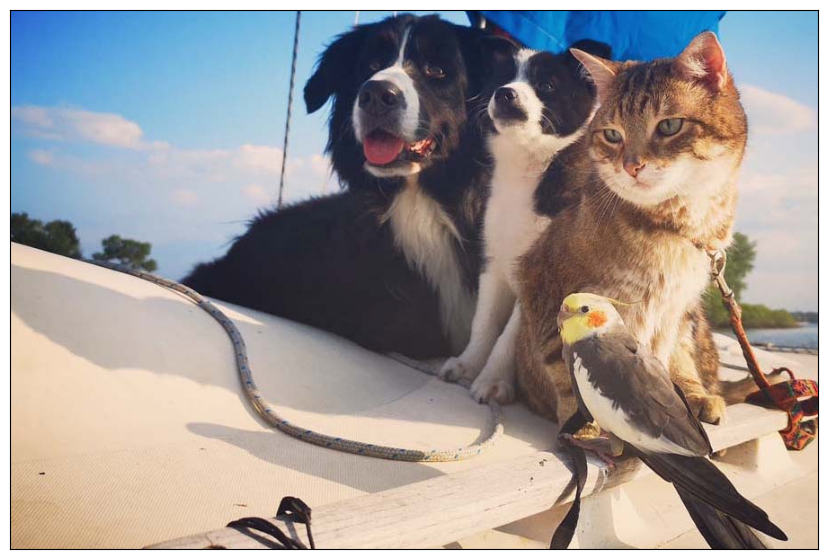

In [6]:
image_np, image_tens = get_tens_from_path('imgs/dog_cat_bird.jpg')
models = {}
model_paths = {}

for model in ['resnet101']:
    for do_polar in [False, True]:
        args.do_polar = do_polar
        model_filename = get_filename('cached_data', datetag, 'bbox', model, do_polar) + '.pt'
        models[model_filename] = load_model(model_name=model, model_path=model_filename, do_circular=args.do_polar).to(device).eval()

#likelihood_maps, povs = [], []
povs = []


for task in ['dog', 'cat', 'bird']:
    test_match = match[task]
#for task in ['leopard', 'jaguar', 'cheetah']:
#    test_match = i_labels_dico[task]# limpkin label
    likelihood_maps = []
    with torch.no_grad():
        image_tens = image_tens.to(device)
        
        data_grid = {}
    
        since_heat = time.time()
            
        data_grid[False] = data_transforms[False](image_tens)
        
        likelihood_map = get_batch(args, model_raw, data_grid[False], 50)
    
        print(time.time() - since_heat, 'Model raw')
    
        likelihood_maps.append(likelihood_map)
    
        likelihood_map = likelihood_map[:,test_match].sum(axis=1)
        
        povs.append(data_grid[False][np.argmax(likelihood_map)].cpu())
        
        for model_name in models.keys():
            do_polar = True if 'retino' in model_name else False
            args.do_polar = do_polar
            
            since_heat = time.time()
            if do_polar == True:
                data_grid[do_polar] = data_transforms[do_polar](image_tens)
            likelihood_map = get_batch(args, models[model_name], data_grid[do_polar], 50)
    
            print(time.time() - since_heat, model_name)
    
            likelihood_maps.append(likelihood_map)
    
            likelihood_map = likelihood_map[:,test_match].sum(axis=1)
    
            
            povs.append(data_grid[False][np.argmax(likelihood_map)].cpu())
    
    display_heat_two(image_np, likelihood_maps, test_match, args.resolution, f'test_heatmap', False)
imshow(povs)

## Test one networks

loading .... cached_data/2025-03-06_bbox_resnet101_retino.pt


NameError: name 'data_transforms' is not defined

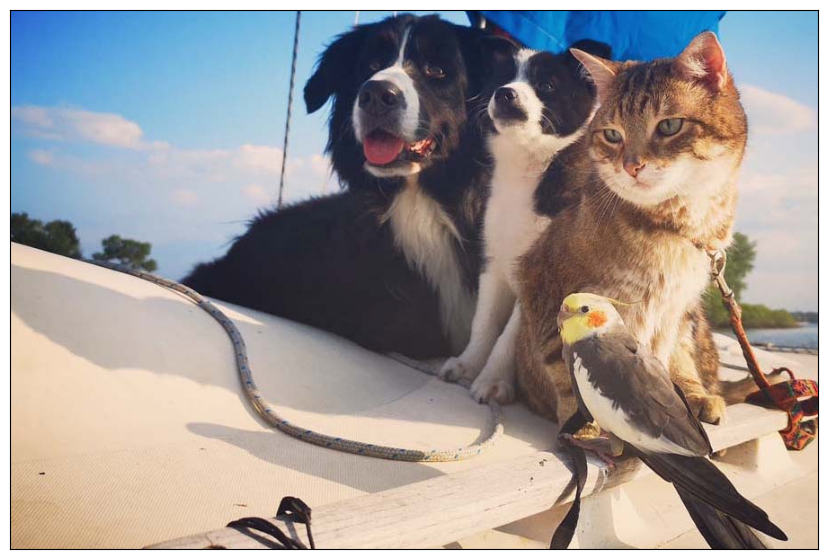

In [7]:
image_np, image_tens = get_tens_from_path('imgs/dog_cat_bird.jpg') 
models = {}
model_paths = {}

for model in ['resnet101']:
    for do_polar in [True]:
        args.do_polar = do_polar
        model_filename = get_filename('cached_data', datetag, 'bbox', model, do_polar) + '.pt'
        models[model_filename] = load_model(model_name=model, model_path=model_filename, do_circular=args.do_polar).to(device).eval()

#likelihood_maps, povs = [], []
povs = []

likelihood_maps = []


for task in ['dog', 'cat', 'bird']:
    test_match = match[task]


    with torch.no_grad():
        image_tens = image_tens.to(device)
        
        data_grid = {}
            
        data_grid[False] = data_transforms[False](image_tens)
        
        
        for model_name in models.keys():
            do_polar = True if 'retino' in model_name else False
            args.do_polar = do_polar
            
            since_heat = time.time()
            
            if do_polar == True:
                
                data_grid[do_polar] = data_transforms[do_polar](image_tens)
            likelihood_map = get_batch(args, models[model_name], data_grid[do_polar], 50)
    
            print(time.time() - since_heat, model_name)

            #
    likelihood_maps.append(likelihood_map)
    
    likelihood_map_match = likelihood_map[:,test_match].sum(axis=1)
    povs.append(data_grid[False][np.argmax(likelihood_map_match)].cpu())
    
display_heat_two(image_np, likelihood_maps, test_match, args.resolution, False, 'multiple_label_map')
imshow(povs, save=False, name='multiple_label_pov')


In [8]:
sample_dis = [43976]

labels_dis = ['Umbrella']
for i_image, ind in enumerate(sample_dis): 
    ind = int(ind)
    (image_tens, true_label) = image_dataset[ind]
    image_np  = imgs_to_np(image_tens)
    imshow(image_tens)

NameError: name 'image_dataset' is not defined

In [9]:
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle
def imshow_heat_boxes(img_list, resolution, boxes, title=None): #allow to display the input image

    images = torchvision.utils.make_grid(img_list)
    stride_y = image_tens.shape[1]//args.resolution[0]
    stride_x = image_tens.shape[2]//args.resolution[1]

    
    
    fig = plt.figure(figsize=(5*len(img_list),5))
    """Imshow for Tensor."""
    inp = images.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)

    ax = plt.gca()

    pos_one = args.resolution[1]
    
    for i, box in enumerate(boxes):
        
        rect = Rectangle((int(box['xmin']),int(box['ymin'])),(int(box['xmax'])-int(box['xmin'])),(int(box['ymax'])-int(box['ymin'])),
                         linewidth=1 if i != 10 else 3, edgecolor=color_dict[i],facecolor='none')
        x_cerc = int((box['xmin'] + box['xmax']) / 2)
        y_cerc = int((box['ymin'] + box['ymax']) / 2)
        circ = Circle((x_cerc, y_cerc), radius=.2, linewidth=1 if i != 10 else 5, edgecolor='black',facecolor='none')
        ax.add_patch(circ)
        ax.add_patch(rect)
        
    plt.xticks([]) ; plt.yticks([])
    if title is not None: plt.title(title)
    plt.tight_layout()
    fig.set_facecolor(color='white')
    plt.show()

In [10]:
cmap = plt.cm.get_cmap('viridis')
color_dict = pd.Series({k:cmap(i/len(np.linspace(0, (args.resolution[0]+1)*(args.resolution[1]+1), ((args.resolution[0]+1)*(args.resolution[1]+1)+1), dtype=int))) for i,k in enumerate(np.linspace(0, (args.resolution[0]+1)*(args.resolution[1]+1), ((args.resolution[0]+1)*(args.resolution[1]+1)+1), dtype=int))})

/tmp/ipykernel_2881694/109576596.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


In [11]:
boxes_ = []

stride_y = image_tens.shape[1]/args.resolution[0]
stride_x = image_tens.shape[2]/args.resolution[1]
pred_box_0 = {'xmax': 3*stride_x, 'xmin': 0, 
            'ymax': 3*stride_y, 'ymin': 0}
#boxes_.append(pred_box)

for x in np.linspace(0, (args.resolution[1]-3), (args.resolution[1]-2), dtype=int):
    for y in np.linspace(0, (args.resolution[0]-3), (args.resolution[0]-2), dtype=int):
        xmin = (x*stride_x)
        ymin = (y*stride_y)
        pred_box = {'xmax': xmin + 3*stride_x, 'xmin': xmin, 
                    'ymax': ymin + 3*stride_y, 'ymin': ymin}
        boxes_.append(pred_box)
imshow_heat_boxes(image_tens, args.resolution, boxes_)

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

<Figure size 1500x500 with 0 Axes>

In [12]:
def imshow_heat_boxes(img_list, resolution, boxes, fig_height=5, ax=None, title=None, save=False, name=None): #allow to display the input image
    if ax is None:
        fig, ax = plt.subplots(figsize=(fig_height*len(img_list), fig_height))
    
    inp = imgs_to_np(img_list, im_mean=im_mean, im_std=im_std)
    plt.imshow(inp)
    
    ax = plt.gca()
    
    for i, box in enumerate(boxes):
        
        rect = Rectangle((int(box['xmin']),int(box['ymin'])),(int(box['xmax'])-int(box['xmin'])),(int(box['ymax'])-int(box['ymin'])),
                         linewidth=5, ls= '--', edgecolor=color_dict[i],facecolor='none')
        x_cerc = int((box['xmin'] + box['xmax']) / 2)
        y_cerc = int((box['ymin'] + box['ymax']) / 2)
        #radius = max((int(box['xmax'] + box['xmin']), int(box['ymax'] + box['ymin'])) ) // 2
        circ = Circle((x_cerc, y_cerc), radius=5, linewidth= 3, edgecolor='blue',facecolor='none')
        ax.add_patch(circ)
        ax.add_patch(rect)
        
    plt.xticks([]) ; plt.yticks([])
    if title is not None: plt.title(title)
    plt.tight_layout()
    plt.show()

    if save : to_save(fig, name='title_doc')

In [13]:
all_ratios = np.linspace(1, .25, round_up(args.resolution[0],2))
cmap = plt.cm.get_cmap('viridis')
color_dict = pd.Series({k:cmap(i/len(np.linspace(0, len(all_ratios), len(all_ratios)+1, dtype=int))) for i,k in enumerate(np.linspace(0, len(all_ratios), len(all_ratios)+1, dtype=int))})

/tmp/ipykernel_2881694/3058852539.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


510.0 764.15
420.0 629.3
330.0 494.45000000000005
240.0 359.6
150.0 224.75


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

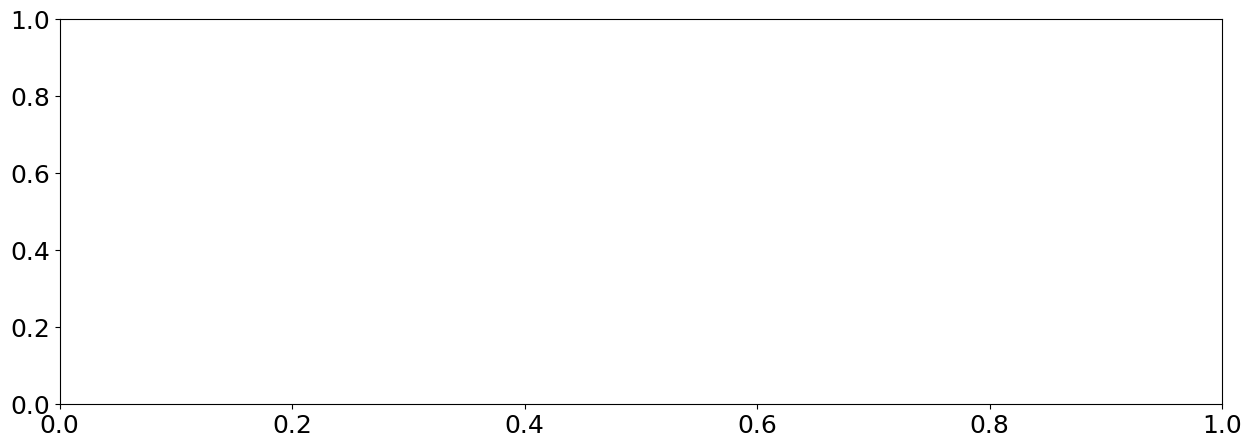

In [14]:
#all_ratios = np.linspace(1, args.size_ratio, round_up(args.resolution[0],2))
#args.image_size = 500
#image_tens = clean_resize(args, image_tens)
args.resolution = (11,11)
#all_ratios = np.linspace(1, 0.1, round_up(args.resolution[0],2))
boxes_ = []
full_size = (image_tens.shape[1]*0.99, image_tens.shape[2]*0.99)
pred_box_0 = {'xmax': full_size[1], 'xmin': image_tens.shape[2]-full_size[1], 
                'ymax': full_size[0], 'ymin': image_tens.shape[1]-full_size[0] }
boxes_.append(pred_box_0)

for ratio_test in all_ratios[1:]:
    stride_y = (image_tens.shape[1]*ratio_test)
    stride_x = (image_tens.shape[2]*ratio_test)
    print(stride_y, stride_x)
    #stride = min(stride_y, stride_x)
    pred_box_0 = {'xmax': stride_x, 'xmin': 0, 
                'ymax': stride_y, 'ymin': 0}
    boxes_.append(pred_box_0)


imshow_heat_boxes(image_tens, args.resolution, boxes_)

In [15]:
im_dis_cart, im_dis_ret = [],  []

image_tens_cart = data_transforms[False](image_tens.to(device))
image_tens_ret = data_transforms[True](image_tens.to(device))



for i in np.linspace(0,5,6,dtype=int):
    im_dis_cart.append(image_tens_cart[i*11 + i].cpu())
    im_dis_ret.append(image_tens_ret[i*11 + i].cpu())
    
imshow(im_dis_cart, save=False, name='fig-likelihood_map_cart_pov')

imshow_heat_boxes(image_tens, args.resolution, boxes_, save=False, name='fig-likelihood_map_pov')

imshow(im_dis_ret, save=False, name='fig-likelihood_map_ret_pov')

NameError: name 'data_transforms' is not defined